In [224]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import yaml

In [225]:
with open(Path.cwd().parent / 'config' / 'plotting.default.yaml', 'r') as f:
    tech_colors = yaml.safe_load(f)['plotting']['tech_colors']

In [230]:
idx = pd.IndexSlice

bal = pd.read_csv(
    Path.cwd().parent / 'results' / 'csvs' / 'energy_balance.csv', index_col=list(range(3)), header=list(range(5))
).loc[:, idx[:,:,:,'NT+fast']]

In [253]:
bal.columns = bal.columns.get_level_values(-1).astype(int)

mp = pd.read_csv(
    Path.cwd().parent / 'results' / 'csvs' / 'prices.csv', index_col=list(range(1)), header=list(range(5))
).loc[:, idx[:,:,:,'NT+fast']]

In [254]:
price_carriers = [
    'AC',
    'H2',
    # 'NH3',
    # 'co2 sequestered',
    # 'co2 stored',
    # 'coal',
    'gas',
    # 'gas for industry',
    # 'heat<100 industry',
    # 'heat100-200 industry',
    'heat200-500 industry',
    # 'heat>500 industry',
    # 'home battery',
    # 'low voltage',
    'methanol',
    # 'shipping methanol',
    # 'process emissions',
    'solid biomass',
    # 'solid biomass for industry',
    'rural heat',
    # 'urban decentral heat',
    # 'urban central heat',
]

In [255]:
price_carriers

['AC',
 'H2',
 'gas',
 'heat200-500 industry',
 'methanol',
 'solid biomass',
 'rural heat']

In [256]:
mp.columns = mp.columns.get_level_values(-1).astype(int)
# mp = mp.loc['gas']

In [257]:
idx = pd.IndexSlice
gas = bal.loc[idx[:, :, 'gas']]

In [258]:
bal

wiggle                                                          1000  \
component carrier                  bus_carrier                         
Generator Offshore Wind (AC)       AC                   1.334470e+09   
          Offshore Wind (DC)       AC                   3.278694e+07   
          Offshore Wind (Floating) AC                   1.808601e+07   
          Onshore Wind             AC                   1.056767e+09   
          Run of River             AC                   1.622933e+08   
...                                                              ...   
Store     Battery Storage          Battery Storage      3.810000e-03   
          co2 sequestered          co2 sequestered     -4.688234e+06   
          coal                     coal                -1.020000e-03   
          home battery             home battery         3.830000e-03   
          non-sequestered HVC      non-sequestered HVC  7.931300e+08   

wiggle                                                          1125  \
component carrier                  bus_carrier                         
Generator Offshore Wind (AC)       AC                   1.312256e+09   
          Offshore Wind (DC)       AC                   3.284300e+07   
          Offshore Wind (Floating) AC                   1.779755e+07   
          Onshore Wind             AC                   1.006617e+09   
          Run of River             AC                   1.621568e+08   
...                                                              ...   
Store     Battery Storage          Battery Storage      1.840000e-03   
          co2 sequestered          co2 sequestered     -5.421094e+06   
          coal                     coal                -4.900000e-04   
          home battery             home battery         1.850000e-03   
          non-sequestered HVC      non-sequestered HVC  7.931300e+08   

wiggle                                                          1250  \
component carrier                  bus_carrier                         
Generator Offshore Wind (AC)       AC                   1.266118e+09   
          Offshore Wind (DC)       AC                   3.285480e+07   
          Offshore Wind (Floating) AC                   1.735639e+07   
          Onshore Wind             AC                   9.363031e+08   
          Run of River             AC                   1.618123e+08   
...                                                              ...   
Store     Battery Storage          Battery Storage      5.830000e-03   
          co2 sequestered          co2 sequestered     -5.593747e+06   
          coal                     coal                -1.560000e-03   
          home battery             home battery         5.860000e-03   
          non-sequestered HVC      non-sequestered HVC  7.931300e+08   

wiggle                                                          1375  \
component carrier                  bus_carrier                         
Generator Offshore Wind (AC)       AC                   1.202424e+09   
          Offshore Wind (DC)       AC                   3.283327e+07   
          Offshore Wind (Floating) AC                   1.444236e+07   
          Onshore Wind             AC                   9.433146e+08   
          Run of River             AC                   1.617670e+08   
...                                                              ...   
Store     Battery Storage          Battery Storage      4.840000e-03   
          co2 sequestered          co2 sequestered     -5.623696e+06   
          coal                     coal                -1.300000e-03   
          home battery             home battery         4.860000e-03   
          non-sequestered HVC      non-sequestered HVC  7.931300e+08   

wiggle                                                          1500  \
component carrier                  bus_carrier                         
Generator Offshore Wind (AC)       AC                   1.209166e+09   
          Offshore Wind (DC)       A

In [260]:
gascon = gas.loc[gas.sum(axis=1) < 0].abs().mul(1e-6)
gascon.index = gascon.index.droplevel(0)
gascon = gascon.sort_values(gascon.columns[-1])

gasgen = gas.loc[gas.sum(axis=1) > 0].mul(1e-6)
gasgen.index = gasgen.index.droplevel(0)

In [238]:
skippers = [
    'gas for industry CC',
    'heat100-200 industry gas CC',
    'heat200-500 industry gas CC',
    'heat>500 industry gas CC',
    'urban central gas CHP CC',
]

In [239]:
mp

wiggle,1000,1125,1250,1375,1500,1625,1750,1875,2000,2125,...,2875,3000,3125,3250,3375,3500,3625,3750,3875,4000
carrier,,,,,,,,,,,,,,,,,,,,,
AC,121.260866,103.901902,98.258139,89.440157,87.735358,87.271334,82.611385,80.939635,79.086360,77.276310,...,58.767024,55.770373,54.953812,53.038947,49.908560,49.064913,49.074455,49.073864,49.080894,49.085284
EV battery,146.447474,126.522055,120.027006,109.949123,108.033797,107.520678,102.250853,100.363766,98.270952,96.267163,...,74.913580,71.465727,70.531808,68.334387,64.769443,63.812456,63.824940,63.824570,63.832406,63.839538
H2,155.601168,135.999852,129.072186,119.177613,116.518570,116.117356,110.407388,106.395042,102.176684,98.195578,...,57.022051,51.492244,50.264732,47.377774,44.104739,43.131722,43.132089,43.133747,43.121829,43.107095
NH3,145.699665,145.403193,143.685610,144.055655,144.412720,144.488202,145.463308,142.992039,138.911090,134.206615,...,87.594531,80.854125,79.146010,75.518012,71.256252,69.844745,69.838708,69.889257,69.915260,69.951549
agriculture machinery oil,75.472317,75.472317,75.470189,75.472317,75.469481,75.471842,75.471381,75.470919,75.471842,75.471382,...,75.470918,75.470918,75.470190,75.470518,75.470527,75.472317,75.470227,75.471959,75.470154,75.470180
battery,84.840383,73.260153,69.535089,63.727065,62.538973,62.236933,59.264094,58.150346,56.941420,55.748287,...,43.245584,41.204293,40.614511,39.345437,37.119511,36.501471,36.506579,36.506654,36.507305,36.507451
biogas,123.058167,94.207901,85.078144,67.505144,62.369458,61.667191,52.921004,49.679474,46.457081,43.698843,...,15.511099,11.561951,10.653929,8.676069,6.555976,5.880041,5.876885,5.869386,5.866337,5.843528
co2,-66.990777,-66.990778,-66.989778,-66.990776,-66.990166,-66.990777,-66.990776,-66.989963,-66.990777,-66.990776,...,-66.989964,-66.989964,-66.989780,-66.989974,-66.989781,-66.990778,-66.990323,-66.990777,-66.989379,-66.989974
co2 sequestered,-18.987505,-21.258201,-21.981641,-24.600115,-25.624435,-25.363841,-26.340047,-27.684086,-27.975341,-28.561598,...,-34.598849,-35.094079,-35.374518,-35.727183,-35.339582,-35.234383,-35.218873,-35.252959,-35.279534,-35.300994


In [241]:
'''
import pypsa

template = 'base_s_50__3H-T-H-B-I-A-dist1_2035_NT_{}{}.nc'

regular_cost = list()
hike_cost = list()

for wiggle in mp.columns:

    try:
        n = pypsa.Network(Path.cwd().parent /  'results' / 'networks' / template.format(wiggle, ''))
        regular_cost.append(n.statistics()[['Capital Expenditure', 'Operational Expenditure']].sum().sum() / 1e9)
    except FileNotFoundError:
        regular_cost.append(np.nan)

    try:
        n = pypsa.Network(Path.cwd().parent /  'results' / 'networks' / template.format(wiggle, '_50'))
        hike_cost.append(n.statistics()[['Capital Expenditure', 'Operational Expenditure']].sum().sum() / 1e9)
    except FileNotFoundError:
        hike_cost.append(np.nan)
'''

"\nimport pypsa\n\ntemplate = 'base_s_50__3H-T-H-B-I-A-dist1_2035_NT_{}{}.nc'\n\nregular_cost = list()\nhike_cost = list()\n\nfor wiggle in mp.columns:\n\n    try:\n        n = pypsa.Network(Path.cwd().parent /  'results' / 'networks' / template.format(wiggle, ''))\n        regular_cost.append(n.statistics()[['Capital Expenditure', 'Operational Expenditure']].sum().sum() / 1e9)\n    except FileNotFoundError:\n        regular_cost.append(np.nan)\n\n    try:\n        n = pypsa.Network(Path.cwd().parent /  'results' / 'networks' / template.format(wiggle, '_50'))\n        hike_cost.append(n.statistics()[['Capital Expenditure', 'Operational Expenditure']].sum().sum() / 1e9)\n    except FileNotFoundError:\n        hike_cost.append(np.nan)\n"

In [ ]:
system_costs = pd.DataFrame({
    'regular': regular_cost,
    'hike': hike_cost,
}, index=mp.columns)
print(system_costs    )

            regular         hike
wiggle                          
1500    1167.770877  1243.127341
2000    1041.589633  1141.948942
2500    1013.998625  1139.337813
3000     999.116798          NaN
3500     999.792291  1153.815261
4000     998.708436  1152.719417


In [ ]:
system_costs.to_csv('regular_and_hike_system_costs.csv')

In [242]:
system_costs = pd.read_csv('regular_and_hike_system_costs.csv', index_col=0)
system_costs.dropna(inplace=True)
system_costs.index = system_costs.index.astype(int)

In [261]:
gascon.index

Index(['heat>500 industry gas CC', 'gas for industry CC', 'SMR',
       'Combined-Cycle Gas', 'heat100-200 industry gas', 'Open-Cycle Gas',
       'heat200-500 industry gas', 'heat<100 industry gas',
       'heat>500 industry gas', 'rural gas boiler', 'urban central gas boiler',
       'urban decentral gas boiler', 'urban central gas CHP',
       'gas for industry', 'SMR CC'],
      dtype='object', name='carrier')

/tmp/ipykernel_206425/509030587.py:187: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_price.set_yticklabels(yticklabels)
/tmp/ipykernel_206425/509030587.py:324: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


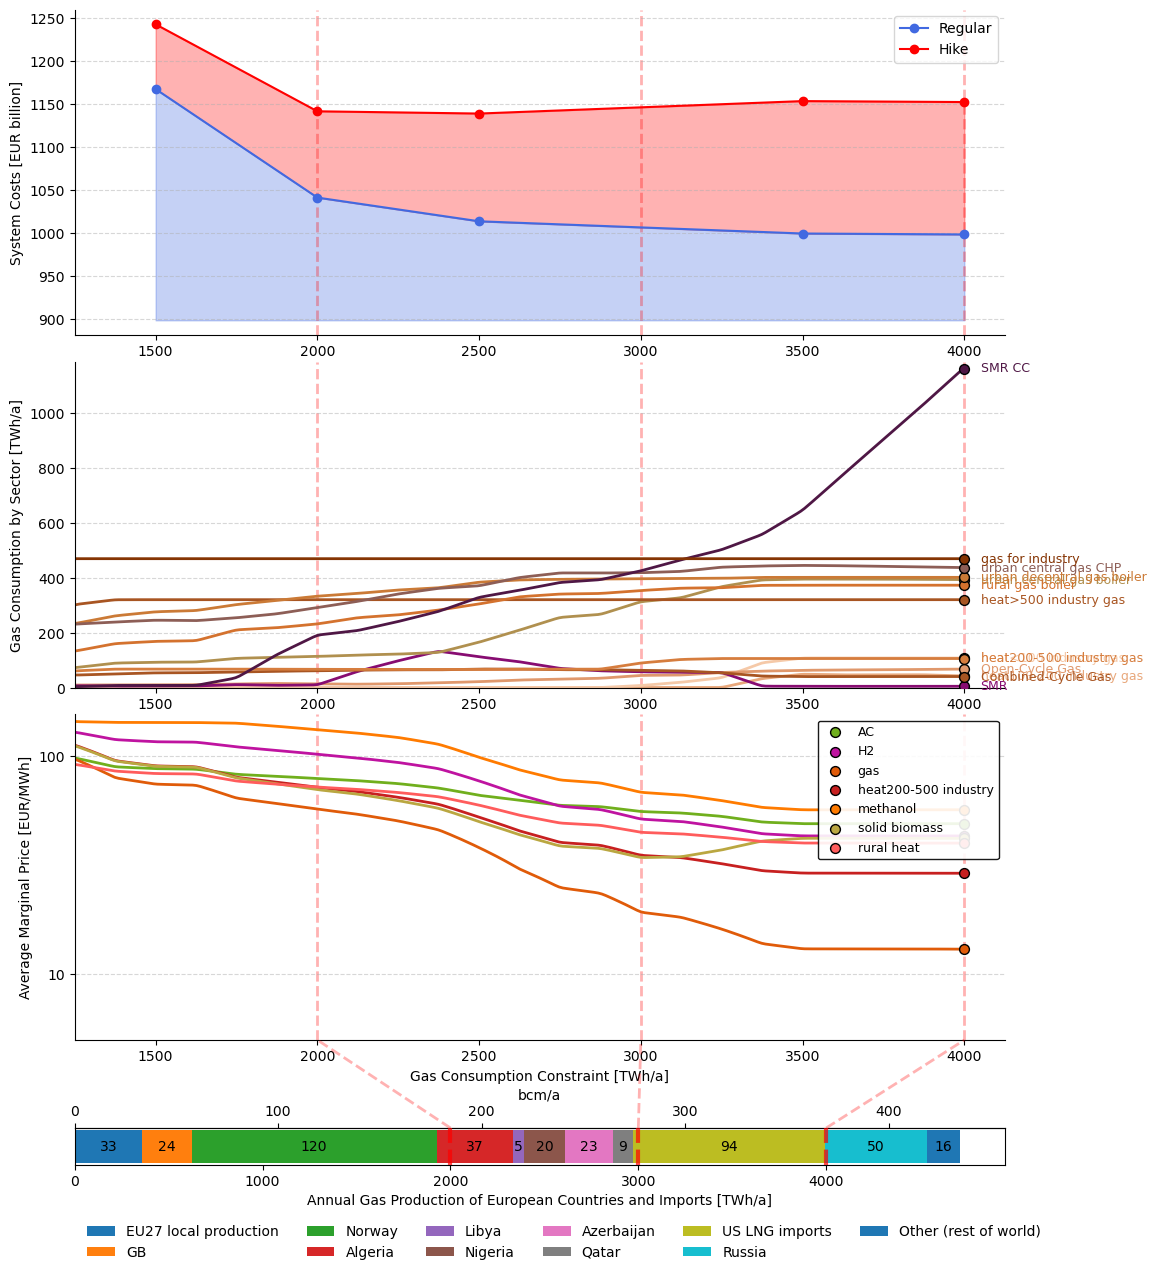

In [244]:
from scipy.ndimage import gaussian_filter1d

# Load tech colors from config
import yaml
with open('../config/plotting.default.yaml', 'r') as f:
    config = yaml.safe_load(f)
tech_colors = config['plotting']['tech_colors']

fig = plt.figure(figsize=(12, 15))
gs = fig.add_gridspec(4, 1, height_ratios=[2, 2, 2, 0.6], hspace=0.1)
ax_sc = fig.add_subplot(gs[0])
ax = fig.add_subplot(gs[1])
ax_price = fig.add_subplot(gs[2])
gs.update(hspace=0.1)
gs2 = fig.add_gridspec(4, 1, height_ratios=[2, 2, 2, 0.6], hspace=2.5)
ax2 = fig.add_subplot(gs2[3])

ax_sc.plot(
    system_costs.index,
    system_costs['regular'],
    color='royalblue',
    marker='o',
    label='Regular',
)
ax_sc.fill_between(
    system_costs.index,
    system_costs['regular'].min() * 0.9,
    system_costs['regular'],
    color='royalblue',
    alpha=0.3,
)
ax_sc.plot(
    system_costs.index,
    system_costs['hike'],
    color='red',
    marker='o',
    label='Hike',
)
ax_sc.fill_between(
    system_costs.index,
    system_costs['regular'],
    system_costs['hike'],
    color='red',
    alpha=0.3,
)

ax_sc.set_ylabel('System Costs [EUR billion]')
ax_sc.grid(linestyle='--', alpha=0.5, axis='y')
ax_sc.legend(loc='upper right')

# Get the max y-value for the background
y_max = gascon.max().max() + 20

# Track lines for legend
lines_for_legend = []
labels_for_legend = []

for carrier in gascon.index:
    if carrier in skippers:
        continue

    # Original data points
    x = gascon.columns.values
    y = gascon.loc[carrier].values

    # Create interpolated points for smoother curve
    from scipy.interpolate import interp1d
    x_interp = np.linspace(x.min(), x.max(), len(x) * 10)
    f = interp1d(x, y, kind='linear')
    y_interp = f(x_interp)

    # Apply Gaussian smoothing (exponential-based, highly localized)
    # sigma controls the smoothing width - smaller values = more localized
    y_smooth = gaussian_filter1d(y_interp, sigma=0.8)

    # Get color from tech_colors dict, fallback to gray if not found
    color = tech_colors.get(carrier, '#808080')

    line = ax.plot(
        x_interp,
        y_smooth,
        linewidth=2,
        color=color,
        label=carrier
    )

    # Add scatter points at the beginning and end of each line
    ax.scatter(
        [x_interp[0], x_interp[-1]],
        [y_smooth[0], y_smooth[-1]],
        color=color,
        s=50,
        zorder=5,
        edgecolors='k',
        linewidths=1
    )

    # Add text label at the end of the line
    ax.text(
        x_interp[-1] + 50,
        y_smooth[-1],
        carrier,
        fontsize=9,
        verticalalignment='center',
        color=color
    )

    lines_for_legend.append(line[0])
    labels_for_legend.append(carrier)

ax.set_ylabel('Gas Consumption by Sector [TWh/a]')

ax.set_xlim(1250, 4125)
ax.set_ylim(0, y_max)

ax.grid(linestyle='--', alpha=0.5, axis='y')


# Track lines for price legend
lines_for_price_legend = []
labels_for_price_legend = []

# Get symmetric y-axis limits
y_max_price = mp.loc[mp.index.intersection(price_carriers)].abs().max().max()
y_min_price = mp.loc[mp.index.intersection(price_carriers)].min().min()

for carrier in price_carriers:
    if carrier not in mp.index:
        continue
    
    # Original data points
    x = mp.columns.values
    y = mp.loc[carrier].values
    
    # Create interpolated points for smoother curve
    from scipy.interpolate import interp1d
    x_interp = np.linspace(x.min(), x.max(), len(x) * 10)
    f = interp1d(x, y, kind='linear')
    y_interp = f(x_interp)
    
    # Apply Gaussian smoothing
    y_smooth = gaussian_filter1d(y_interp, sigma=0.8)
    
    # Get color from tech_colors dict, fallback to gray if not found
    color = tech_colors.get(carrier, '#808080')
    
    line = ax_price.plot(
        x_interp,
        y_smooth,
        linewidth=2,
        color=color,
        label=carrier
    )

    # Add scatter points at the beginning and end of each line
    scatter = ax_price.scatter(
        [x_interp[0], x_interp[-1]],
        [y_smooth[0], y_smooth[-1]],
        color=color,
        s=50,
        zorder=5,
        edgecolors='k',
        linewidths=1
    )

    lines_for_price_legend.append(scatter)
    labels_for_price_legend.append(carrier)

ax_price.set_xlabel('Gas Consumption Constraint [TWh/a]')
ax_price.set_ylabel('Average Marginal Price [EUR/MWh]')

ax_price.set_ylim(5, y_max_price)
ax_price.axhline(0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
ax_price.set_yscale('symlog', linthresh=1)
ax_price.grid(linestyle='--', alpha=0.5, axis='y')

# Custom y-tick labels
yticks = ax_price.get_yticks()
yticklabels = []
for tick in yticks:
    if tick == 1000:
        yticklabels.append('1000')
    elif tick == 100:
        yticklabels.append('100')
    else:
        yticklabels.append(f'{tick:.0f}')
ax_price.set_yticklabels(yticklabels)

# Add legend to the center plot (ax_price)
ax_price.legend(
    lines_for_price_legend,
    labels_for_price_legend,
    loc='upper right',
    fontsize=9,
    framealpha=0.9,
    edgecolor='black'
)

for a in [ax_sc, ax, ax_price]:
    a.set_xlim(1250, 4125)
    a.spines['right'].set_visible(False)
    a.spines['top'].set_visible(False)

TWH_PER_BCM = 10.83  # typical HHV/GCV-ish conversion used in many EU gas contexts

# Conversion used: 1 bcm ≈ 35.8 PJ = 35_800 TJ (typical LHV-based rule of thumb)
TJ_per_bcm = 35_800

gas_bcm_2025_by_origin = {
    "Romania":      359_943 / TJ_per_bcm,  # ≈ 10.05 bcm
    "Netherlands":  322_642 / TJ_per_bcm,  # ≈  9.01 bcm
    "Germany":      136_227 / TJ_per_bcm,  # ≈  3.81 bcm
}

# optional: rounded view
gas_bcm_2025_by_origin_rounded = {k: round(v, 2) for k, v in gas_bcm_2025_by_origin.items()}
gas_bcm_2025_by_origin_rounded


gas_bcm_2025_by_origin = {
    "EU27 local production": 33.0,     # ~4 * (8 bcm in Q2 2025) proxy :contentReference[oaicite:0]{index=0}
    "Norway": 120.4,                   # NOD 2025 production forecast :contentReference[oaicite:1]{index=1}
    "GB": 24.5,                        # UK annual production expectation (NSTA-based) :contentReference[oaicite:2]{index=2}

    "Azerbaijan": 23.5116072041,
    "Qatar": 9.8011006471,
    "US LNG imports": 94.5567955626,

    "Algeria": 37.5,
    "Libya": 5.6,

    "Russia": 50.0,
    "Nigeria": 20.0,
    "Other (rest of world)": 16.4987053062,
}


# gas_bcm_2025_by_origin.update({
    # "GB": 27.9837955016,
    # "Norway": 124.,
    # "northern-african imports": 43.0788492119,  # Algeria (LNG+pipeline) + Libya (pipeline)
    # "Azerbaijan": 23.5116072041,
    # "Qatar": 9.8011006471,
    # "US LNG imports": 94.5567955626,
    # "Other": 86.4987053062,                 # includes e.g. Russia, Nigeria, etc.
# })

# Plot order requested
order = [
    "EU27 local production",
    "GB",
    "Norway",
    "Algeria",
    "Libya",
    "Nigeria",
    "Azerbaijan",
    "Qatar",
    "US LNG imports",
    "Russia",
    "Other (rest of world)",
]

# Convert to TWh for bottom axis (plotting axis)
vals_bcm = [gas_bcm_2025_by_origin[k] for k in order]
vals_twh = [v * TWH_PER_BCM for v in vals_bcm]

# Create stacked bar plot in third subplot
left = 0
for i, (label, twh, bcm) in enumerate(zip(order, vals_twh, vals_bcm)):
    ax2.barh(0, twh, left=left, label=label)
    # Add text label in the middle of each segment
    if twh > 0:
        ax2.text(left + twh/2, 0, f"{int(bcm)}", va="center", ha="center")
    left += twh

ax2.set_yticks([])
ax2.set_xlabel("Annual Gas Production of European Countries and Imports [TWh/a]")
ax2.legend(loc='upper left', bbox_to_anchor=(-0., -1.3), ncol=len(order)//2 + 1, frameon=False)

# Secondary (top) axis in bcm
secax = ax2.secondary_xaxis(
    "top",
    functions=(lambda twh: twh / TWH_PER_BCM, lambda bcm: bcm * TWH_PER_BCM),
)
secax.set_xlabel("bcm/a")

# Add vertical lines at important values on ax2
for x_val in [2000, 3000, 4000]:
    ax2.axvline(x_val, color='r', linestyle='--', linewidth=3, alpha=0.7, zorder=10)

# Add continuous vertical lines across the upper three axes with lower alpha
for x_val in [2000, 3000, 4000]:
    # Draw lines with lower alpha on the upper three axes
    for a in [ax_sc, ax, ax_price]:
        a.axvline(x_val, color='r', linestyle='--', linewidth=2, alpha=0.3, zorder=1)

# Add diagonal lines connecting ax2 to ax_price
for x_val in [2000, 3000, 4000]:
    # Get the figure coordinates for the connection points
    # Bottom point: top of ax2 at x_val
    # Top point: bottom of ax_price at x_val
    
    # Transform x_val to figure coordinates for ax2 (top edge)
    ax2_trans = ax2.transData.transform([(x_val, ax2.get_ylim()[1])])[0]
    ax2_fig = fig.transFigure.inverted().transform(ax2_trans)
    
    # Transform x_val to figure coordinates for ax_price (bottom edge)
    ax_price_trans = ax_price.transData.transform([(x_val, ax_price.get_ylim()[0])])[0]
    ax_price_fig = fig.transFigure.inverted().transform(ax_price_trans)
    
    # Draw line in figure coordinates
    line = plt.Line2D(
        [ax2_fig[0], ax_price_fig[0]],
        [ax2_fig[1], ax_price_fig[1]],
        transform=fig.transFigure,
        color='r',
        linestyle='--',
        linewidth=2,
        alpha=0.3,
        zorder=1
    )
    fig.add_artist(line)

plt.tight_layout()
plt.show()

In [262]:
gascon

wiggle,1000,1125,1250,1375,1500,1625,1750,1875,2000,2125,...,2875,3000,3125,3250,3375,3500,3625,3750,3875,4000
carrier,,,,,,,,,,,,,,,,,,,,,
heat>500 industry gas CC,0.002646,0.002184,0.004599,0.006189,0.005784,0.007009,0.006461,0.004725,0.007772,0.004847,...,0.009237,0.006975,0.009111,0.013625,0.005710,0.006781,0.003753,0.008689,0.000060,0.007829
gas for industry CC,0.006480,0.004984,0.010132,0.013966,0.012861,0.012829,0.012257,0.008961,0.012487,0.009010,...,0.013594,0.011649,0.016068,0.024216,0.011651,0.068885,0.063596,0.071434,0.057720,0.070288
SMR,20.379332,6.510153,6.732117,5.241725,5.676203,5.766921,10.782200,8.047276,9.790369,58.914524,...,60.860459,57.236917,55.478373,54.962484,4.948819,4.520117,4.470949,4.347243,4.404799,4.662277
Combined-Cycle Gas,64.234130,49.997303,45.302995,49.717697,53.483173,54.058140,56.671483,59.480596,60.873417,63.296565,...,64.965175,62.382532,60.494689,53.637701,41.728428,39.816173,39.816756,39.804368,39.747873,40.068281
heat100-200 industry gas,0.000571,0.000404,0.000848,0.001243,0.001228,0.001486,0.001436,0.001170,0.001951,0.001404,...,0.007054,0.008303,0.012756,0.036254,32.761899,48.675121,45.966727,46.459772,46.425359,42.149802
Open-Cycle Gas,4.137294,8.669005,9.241608,9.805270,10.281272,10.445065,13.221193,14.909432,13.400975,12.151712,...,33.675592,44.205146,45.521414,54.731658,59.783340,62.689591,64.115127,64.696338,65.875482,67.225623
heat200-500 industry gas,29.913770,40.811256,60.546536,67.082229,67.128512,67.187873,67.146634,66.601822,66.238512,66.032474,...,66.713270,89.365934,102.343522,105.630801,105.637226,105.636522,105.638187,105.635539,105.639977,105.635785
heat<100 industry gas,0.000605,0.000426,0.000879,0.001298,0.001264,0.001520,0.001502,0.001215,0.002069,0.001488,...,0.009212,7.361089,19.188959,35.638449,90.376896,107.397264,107.397684,107.398579,107.400181,107.355023
heat>500 industry gas,169.512780,230.867507,301.942498,319.586004,319.732627,319.731334,319.732866,319.734767,319.731376,319.734447,...,319.729483,319.732200,319.729486,319.724556,319.733689,319.732379,319.735847,319.730202,319.739934,319.730966


In [263]:
ref = gascon.iloc[:,-1]
dis = gascon.iloc[:,:-1]

threshold_share = 0.5
gasuse_baseline = 4000 # TWh

displaced = dis.sub(ref, axis=0).abs()

df = pd.DataFrame(index=displaced.index, columns=['phase_out_prices', 'phase_out_volume'])

for carrier in displaced.index:

    ss = displaced.loc[carrier]
    ss = ss[ss > threshold_share * ss.max()]

    if not len(ss):
        continue

    df.loc[carrier, 'phase_out_prices'] = mp.loc['gas', ss.index[-1]]
    df.loc[carrier, 'phase_out_volume'] = gasuse_baseline - ss.index[-1]

df.sort_values(by='phase_out_prices', ascending=True, inplace=True)
df.dropna(inplace=True)

In [246]:
bal = pd.read_csv(
    Path.cwd().parent / 'results' / 'csvs' / 'energy_balance.csv', index_col=list(range(3)), header=list(range(5))
).loc[:, idx[:,:,:,'NT+fast']]
bal.columns = bal.columns.get_level_values(-1).astype(int)

mp = pd.read_csv(
    Path.cwd().parent / 'results' / 'csvs' / 'prices.csv', index_col=list(range(1)), header=list(range(5))
)

In [265]:
xlim_lower = df['phase_out_volume'].min()
xlim_upper = df['phase_out_volume'].max() + 100

/tmp/ipykernel_206425/3760031978.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['10', '100', '1000'])


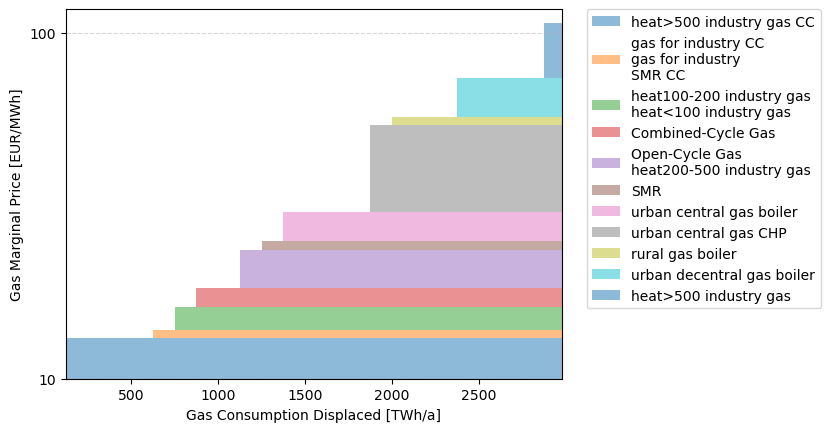

In [266]:
fig, ax = plt.subplots()

labels, handles = [], []

for i, price in enumerate(df['phase_out_prices'].unique()):

    ss = df.loc[df['phase_out_prices'] == price]


    if i == 0:
        lower = 10
    else:
        lower = upper

    upper = price
    text = '\n'.join(ss.index)

    usage = ss['phase_out_volume'].max()
    ax.fill_between([usage, xlim_upper], lower, upper, alpha=0.5, label=text)

    # ax.text(usage + 50, (lower + upper) / 2, text, ha='left', va='center', fontsize=10)

ax.set_yscale('symlog', linthresh=10)
ax.set_ylim(10, df['phase_out_prices'].max() * 1.1)

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
ax.set_xlim(xlim_lower, xlim_upper)
ax.grid(linestyle='--', alpha=0.5, axis='y')

ax.set_yticklabels(['10', '100', '1000'])

ax.set_xlabel('Gas Consumption Displaced [TWh/a]')
ax.set_ylabel('Gas Marginal Price [EUR/MWh]')

plt.show()

In [473]:
items = [
    # "heat>500 industry gas CC",
    "gas for industry",
    "heat>500 industry gas",
    "heat200-500 industry gas",
    # "gas for industry CC",
    # "Open-Cycle Gas",
    # "Combined-Cycle Gas",
    "gas turbine",
    "residential gas boiler",
    "urban central gas CHP",
    "SMR CC",
    "SMR",
    "heat<100 industry gas",
    "heat100-200 industry gas",
    "biogas to gas",
]

In [474]:
tech_colors['residential gas boiler'] = tech_colors['urban decentral gas boiler']
tech_colors['gas turbine'] = tech_colors['Open-Cycle Gas']

In [519]:
gb = bal.loc[:,:,'gas'].mul(1e-6)
gb.index = gb.index.get_level_values(1)
gb.drop('gas', inplace=True)

Index(['Combined-Cycle Gas', 'Open-Cycle Gas', 'SMR', 'SMR CC', 'Sabatier',
       'biogas to gas', 'gas for industry', 'gas for industry CC',
       'heat100-200 industry gas', 'heat200-500 industry gas',
       'heat<100 industry gas', 'heat>500 industry gas',
       'heat>500 industry gas CC', 'rural gas boiler', 'urban central gas CHP',
       'urban central gas boiler', 'urban decentral gas boiler'],
      dtype='object', name='carrier')


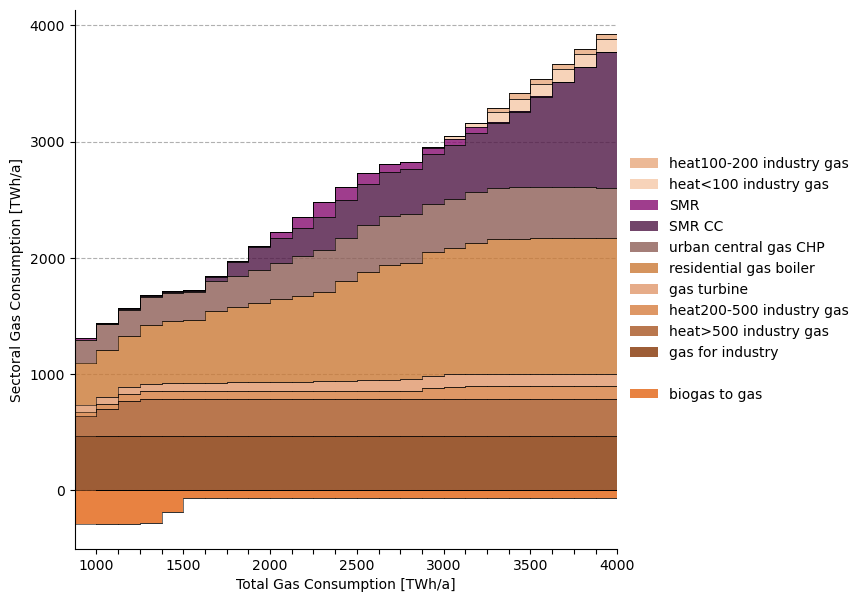

In [ ]:
print(gb.index)
carrier_mapping = {
    'urban decentral gas boiler': 'residential gas boiler',
    'urban central gas boiler': 'residential gas boiler',
    'rural gas boiler': 'residential gas boiler',
    'Open-Cycle Gas': 'gas turbine',
    'Combined-Cycle Gas': 'gas turbine',
}

for carrier in items:
    if carrier in carrier_mapping:
        continue

    carrier_mapping[carrier] = carrier_mapping.get(carrier, carrier)

gb = gb.groupby(carrier_mapping).sum()

line_kwargs = {
    'color': 'k',
    'linewidth': 0.5,
    'alpha': 0.8
}

fig, ax = plt.subplots(figsize=(7, 7))
ax.axhline(0, **line_kwargs)

bottoms = pd.Series(0, index=gb.columns, dtype=float)
ceilings = pd.Series(0, index=gb.columns, dtype=float)

width = 1

for i, carrier in enumerate(items):

    row = gb.loc[carrier]
    
    for j, con in enumerate(row.index):

        value = row.loc[con] * (-1)

        if value < 0:

            ax.bar(
                j,
                value,
                bottom=ceilings.loc[con],
                color=tech_colors[carrier],
                alpha=0.8,
                width=1
                )
            ceilings.loc[con] += value

            ax.plot(
                [j-width/2, j+width/2],
                [ceilings.loc[con], ceilings.loc[con]],
                **line_kwargs
            )

        else:

            ax.bar(
                j,
                value,
                bottom=bottoms.loc[con],
                color=tech_colors[carrier],
                alpha=0.8,
                width=1
            )

            bottoms.loc[con] += value

            ax.plot(
                [j-width/2, j+width/2],
                [bottoms.loc[con], bottoms.loc[con]],
                **line_kwargs
            )
    
    ax.step(
        np.arange(len(bottoms)) + width/2,
        bottoms.values,
        **line_kwargs
    )
    ax.step(
        np.arange(len(bottoms)) + width/2,
        ceilings.values,
        **line_kwargs
    )

ax.set_xlim(-width/2, len(bottoms) - width/2)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.grid(linestyle='--', alpha=1, axis='y')
ax.set_axisbelow(True)

ax.set_xticks(np.arange(len(bottoms)) + width/2)
ax.set_xticklabels(
    [label if i % 4 == 0 else '' for i, label in enumerate(bottoms.index)],
    rotation=0
)

# Add legend on the right side
handles = []
labels = []
for carrier in items[::-1]:
    if carrier == 'biogas to gas':
        continue

    if carrier in tech_colors:
        handles.append(plt.Rectangle((0, 0), 1, 1, fc=tech_colors[carrier], alpha=0.8))
        labels.append(carrier)

from matplotlib.lines import Line2D

handles.append(Line2D([0], [0], color='w', lw=0.5, alpha=0.8))
labels.append('')

labels.append('biogas to gas')
handles.append(plt.Rectangle((0, 0), 1, 1, fc=tech_colors['biogas to gas'], alpha=0.8))

ax.legend(handles, labels, loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)

ax.set_xlabel('Total Gas Consumption [TWh/a]')
ax.set_ylabel('Sectoral Gas Consumption [TWh/a]')

plt.show()

In [472]:
import pypsa
n = pypsa.Network(
    Path.cwd().parent / 'results' / 'networks' /
    'base_s_50__168H-T-H-B-I-A-dist1_2030_NT+fast_2500.nc'
    )

INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2030_NT+fast_2500.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [476]:
n.buses.carrier.unique()

array(['AC', 'none', 'co2', 'co2 stored', 'co2 sequestered', 'gas', 'H2',
       'battery', 'EV battery', 'oil', 'oil primary',
       'land transport oil', 'urban central heat', 'biogas',
       'solid biomass', 'unsustainable bioliquids', 'NH3', 'methanol',
       'solid biomass for industry', 'heat<100 industry',
       'heat100-200 industry', 'heat200-500 industry',
       'heat>500 industry', 'gas for industry', 'industry methanol',
       'naphtha for industry', 'non-sequestered HVC', 'process emissions',
       'coal', 'coal for industry', 'shipping methanol', 'shipping oil',
       'kerosene for aviation', 'agriculture machinery oil',
       'low voltage', 'home battery', 'rural heat',
       'urban decentral heat'], dtype=object)

In [499]:
bal.index.unique(2)

Index(['AC', 'biogas', 'co2', 'coal', 'gas', 'oil primary', 'rural heat',
       'solid biomass', 'unsustainable bioliquids', 'urban central heat',
       'urban decentral heat', 'EV battery', 'low voltage', 'Hydrogen Storage',
       'co2 stored', 'oil', 'non-sequestered HVC', 'NH3', 'methanol',
       'agriculture machinery oil', 'Battery Storage', 'co2 sequestered',
       'coal for industry', 'gas for industry', 'heat100-200 industry',
       'heat200-500 industry', 'heat<100 industry', 'heat>500 industry',
       'home battery', 'kerosene for aviation', 'land transport oil',
       'naphtha for industry', 'shipping methanol', 'shipping oil',
       'solid biomass for industry'],
      dtype='object', name='bus_carrier')

In [482]:
bal.index.unique(2)

Index(['AC', 'biogas', 'co2', 'coal', 'gas', 'oil primary', 'rural heat',
       'solid biomass', 'unsustainable bioliquids', 'urban central heat',
       'urban decentral heat', 'EV battery', 'low voltage', 'Hydrogen Storage',
       'co2 stored', 'oil', 'non-sequestered HVC', 'NH3', 'methanol',
       'agriculture machinery oil', 'Battery Storage', 'co2 sequestered',
       'coal for industry', 'gas for industry', 'heat100-200 industry',
       'heat200-500 industry', 'heat<100 industry', 'heat>500 industry',
       'home battery', 'kerosene for aviation', 'land transport oil',
       'naphtha for industry', 'shipping methanol', 'shipping oil',
       'solid biomass for industry'],
      dtype='object', name='bus_carrier')

In [536]:
target_bus_carriers = {
    "AC": ["Combined-Cycle Gas", "Open-Cycle Gas"],
    "Hydrogen Storage": ["SMR", "SMR CC"],
    "gas": ["Sabatier"],
    "biogas": ["biogas to gas"],
    "gas for industry": ["gas for industry", "gas for industry CC"],
    "heat100-200 industry": ["heat100-200 industry gas"],
    "heat200-500 industry": ["heat200-500 industry gas"],
    "heat<100 industry": ["heat<100 industry gas"],
    "heat>500 industry": ["heat>500 industry gas", "heat>500 industry gas CC"],
    "rural heat": ["rural gas boiler"],
    "urban central heat": ["urban central gas CHP", "urban central gas boiler"],
    "urban decentral heat": ["urban decentral gas boiler"],
}

gb = bal.loc[:,:,'gas'].mul(1e-6)
gb.index = gb.index.get_level_values(1)
gb.drop('gas', inplace=True)

# gb = bal.loc[:,:,'gas'].mul(1e-6)

threshold = 10 # TWh

displacers = []

# for bus_carrier, gas_carrier in gb.index:
for bus_carrier, gas_carriers in target_bus_carriers.items():
# for carrier in ['heat100-200 industry gas']:

    # if carrier in ['gas for industry', 'gas for industry CC', 'Sabatier']:
    #     continue

    # target_carrier = target_bus_carriers[carrier]

    ss = bal.loc[idx[:,:,bus_carrier]] / 1e6
    ss.index = ss.index.droplevel(0)

    maxgas_col = ss.loc[gas_carriers].sum().idxmax()

    diff = ss.sub(ss.loc[:,maxgas_col], axis=0).drop(gas_carriers)
    # print()
    diff = diff.loc[diff.sum(axis=1) > threshold]

    print(bus_carrier)
    print(gas_carriers)
    print(diff.index)
    print('===================================')
    displacers.append(diff)

AC
['Combined-Cycle Gas', 'Open-Cycle Gas']
Index(['Offshore Wind (AC)', 'Offshore Wind (DC)', 'Offshore Wind (Floating)',
       'Onshore Wind', 'Solar'],
      dtype='object', name='carrier')
Hydrogen Storage
['SMR', 'SMR CC']
Index(['Fischer-Tropsch', 'H2 Electrolysis', 'electrobiofuels'], dtype='object', name='carrier')
gas
['Sabatier']
Index(['gas', 'Combined-Cycle Gas'], dtype='object', name='carrier')
biogas
['biogas to gas']
Index(['biogas'], dtype='object', name='carrier')
gas for industry
['gas for industry', 'gas for industry CC']
Index([], dtype='object', name='carrier')
heat100-200 industry
['heat100-200 industry gas']
Index(['heat100-200 industry industrial heat pump high temperature'], dtype='object', name='carrier')
heat200-500 industry
['heat200-500 industry gas']
Index(['heat200-500 industry hydrogen', 'heat200-500 industry solid biomass'], dtype='object', name='carrier')
heat<100 industry
['heat<100 industry gas']
Index(['heat<100 industry industrial heat pump medium

In [560]:
df = pd.concat(displacers)
df = df.drop(df.index.intersection(gb.index))
df.index

ground_hp_names = df.index[df.index.str.contains('ground heat pump')]
df.loc['ground heat pump'] = df.loc[ground_hp_names].sum(axis=1)
df.drop(ground_hp_names, inplace=True)

air_hp_names = df.index[df.index.str.contains('air heat pump')]
df.loc['air heat pump'] = df.loc[air_hp_names].sum(axis=1)
df.drop(air_hp_names, inplace=True)

solar_thermal_names = df.index[df.index.str.contains('solar thermal')]
df.loc['solar thermal'] = df.loc[solar_thermal_names].sum(axis=1)
df.drop(solar_thermal_names, inplace=True)

df.drop(['gas', 'biogas'], inplace=True)

df = df.groupby(df.index).sum()

df.index

Index(['Fischer-Tropsch', 'H2 Electrolysis', 'Offshore Wind (AC)',
       'Offshore Wind (DC)', 'Offshore Wind (Floating)', 'Onshore Wind',
       'Solar', 'air heat pump', 'electrobiofuels', 'ground heat pump',
       'heat100-200 industry industrial heat pump high temperature',
       'heat200-500 industry hydrogen', 'heat200-500 industry solid biomass',
       'heat<100 industry industrial heat pump medium temperature',
       'heat>500 industry hydrogen', 'solar thermal',
       'urban central solid biomass CHP'],
      dtype='object', name='carrier')

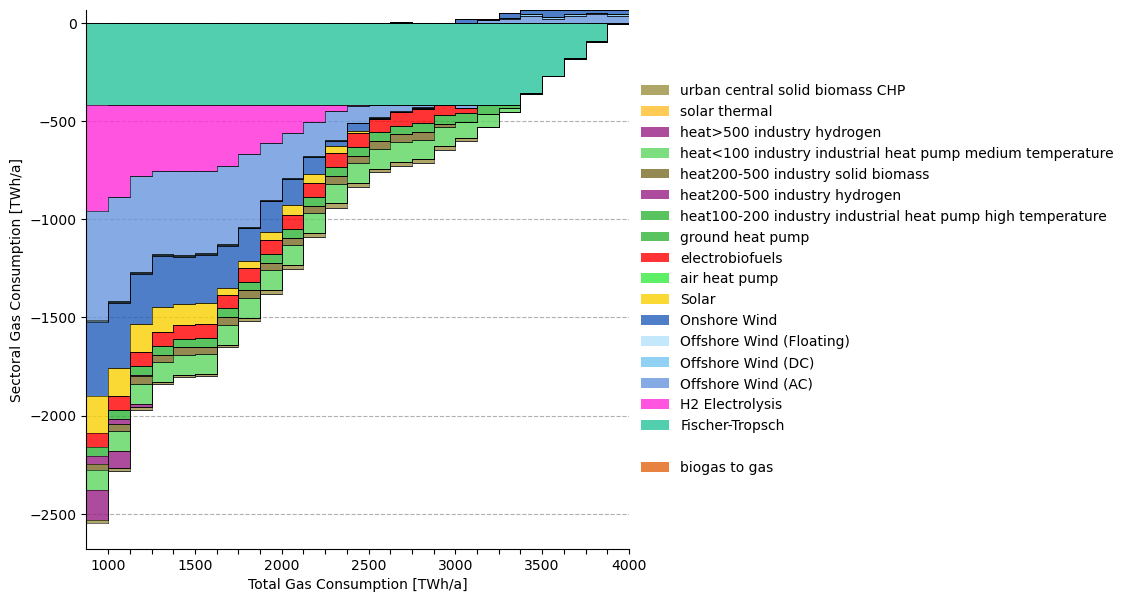

In [562]:

line_kwargs = {
    'color': 'k',
    'linewidth': 0.5,
    'alpha': 0.8
}

fig, ax = plt.subplots(figsize=(7, 7))
ax.axhline(0, **line_kwargs)

bottoms = pd.Series(0, index=df.columns, dtype=float)
ceilings = pd.Series(0, index=df.columns, dtype=float)

width = 1

for i, carrier in enumerate(df.index):

    row = df.loc[carrier]
    
    for j, con in enumerate(row.index):

        value = row.loc[con] * (-1)

        if value < 0:

            ax.bar(
                j,
                value,
                bottom=ceilings.loc[con],
                color=tech_colors[carrier],
                alpha=0.8,
                width=1
                )
            ceilings.loc[con] += value

            ax.plot(
                [j-width/2, j+width/2],
                [ceilings.loc[con], ceilings.loc[con]],
                **line_kwargs
            )

        else:

            ax.bar(
                j,
                value,
                bottom=bottoms.loc[con],
                color=tech_colors[carrier],
                alpha=0.8,
                width=1
            )

            bottoms.loc[con] += value

            ax.plot(
                [j-width/2, j+width/2],
                [bottoms.loc[con], bottoms.loc[con]],
                **line_kwargs
            )
    
    ax.step(
        np.arange(len(bottoms)) + width/2,
        bottoms.values,
        **line_kwargs
    )
    ax.step(
        np.arange(len(bottoms)) + width/2,
        ceilings.values,
        **line_kwargs
    )

ax.set_xlim(-width/2, len(bottoms) - width/2)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.grid(linestyle='--', alpha=1, axis='y')
ax.set_axisbelow(True)

ax.set_xticks(np.arange(len(bottoms)) + width/2)
ax.set_xticklabels(
    [label if i % 4 == 0 else '' for i, label in enumerate(bottoms.index)],
    rotation=0
)

# Add legend on the right side
handles = []
labels = []
for carrier in df.index[::-1]:
    if carrier == 'biogas to gas':
        continue

    if carrier in tech_colors:
        handles.append(plt.Rectangle((0, 0), 1, 1, fc=tech_colors[carrier], alpha=0.8))
        labels.append(carrier)

from matplotlib.lines import Line2D

handles.append(Line2D([0], [0], color='w', lw=0.5, alpha=0.8))
labels.append('')

labels.append('biogas to gas')
handles.append(plt.Rectangle((0, 0), 1, 1, fc=tech_colors['biogas to gas'], alpha=0.8))

ax.legend(handles, labels, loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)

ax.set_xlabel('Total Gas Consumption [TWh/a]')
ax.set_ylabel('Sectoral Gas Consumption [TWh/a]')

plt.show()

In [547]:
df

wiggle,1000,1125,1250,1375,1500,1625,1750,1875,2000,2125,...,2875,3000,3125,3250,3375,3500,3625,3750,3875,4000
carrier,,,,,,,,,,,,,,,,,,,,,
Fischer-Tropsch,419.502110,419.502417,419.501719,419.501269,419.501415,419.501403,419.501530,419.501752,419.500939,419.501332,...,419.496355,419.495300,419.491109,419.192166,418.950645,358.683120,269.103420,180.711304,92.024821,0.000000
H2 Electrolysis,538.645711,464.852379,362.639637,334.996565,334.285936,334.178835,309.385343,248.080549,193.279931,140.341415,...,0.001165,-0.000128,0.000153,0.000383,-0.000408,-0.000131,-0.000519,0.000035,-0.000833,0.000011
Offshore Wind (AC),552.463256,530.249775,484.111734,420.417351,427.159589,415.908148,399.520196,372.613316,291.003501,229.725735,...,10.698442,0.000000,13.416470,-15.266807,-17.816468,-37.077558,-20.756238,-37.106339,-44.295360,-35.649096
Offshore Wind (DC),8.349564,8.405630,8.417426,8.395895,8.519517,8.435048,5.301392,5.335415,5.315314,4.952852,...,1.593905,0.000000,-0.637272,-0.813719,-6.941997,-7.371660,-7.281735,-7.356312,-7.313578,-7.300744
Offshore Wind (Floating),5.623494,5.335033,4.893870,1.979844,1.556239,1.713066,0.572065,0.536514,0.591262,-0.075226,...,-0.000696,0.000000,-0.015045,-0.008487,-0.045597,-0.104681,-0.035523,-0.102457,-0.096341,-0.046058
Onshore Wind,376.784751,326.634827,256.321195,263.332676,239.525608,247.143236,214.200585,165.815125,156.569142,132.483637,...,8.675788,0.000000,-17.309562,-1.691526,-26.493159,-20.870885,-37.809392,-21.299218,-14.854673,-21.617372
Solar,185.723926,144.473570,142.356305,124.874764,106.149661,106.390208,35.093086,34.492479,38.394391,50.653254,...,-0.252526,0.000000,0.582714,0.799519,1.890261,1.720291,1.545312,1.726175,1.950163,1.741604
air heat pump,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
biogas,227.657426,227.657423,227.657388,213.625454,124.237509,3.514257,0.004019,0.004124,0.002706,0.001748,...,0.000808,0.000507,0.000835,0.000918,0.000306,0.000512,0.000228,0.000625,0.000000,0.000605


In [358]:
region_group = {
    "DE": "Central Europe",
    "FR": "Central Europe",
    "AT": "Central Europe",
    "CH": "Central Europe",
    "BE": "Central Europe",
    "NL": "Central Europe",
    "LU": "Central Europe",

    "IT": "Southern Europe",
    "ES": "Southern Europe",
    "PT": "Southern Europe",

    "DK": "Northern and British Isles",
    "NO": "Northern and British Isles",
    "SE": "Northern and British Isles",
    "FI": "Northern and British Isles",
    "GB": "Northern and British Isles",
    "IE": "Northern and British Isles",

    "CZ": "Eastern Europe",
    "PL": "Eastern Europe",
    "SK": "Eastern Europe",
    "HU": "Eastern Europe",
    "RO": "Eastern Europe",
    "BG": "Eastern Europe",
    "SI": "Eastern Europe",
    "HR": "Eastern Europe",
    "EE": "Eastern Europe",
    "LV": "Eastern Europe",
    "LT": "Eastern Europe",

    "AL": "Balkans & Greece",
    "BA": "Balkans & Greece",
    "ME": "Balkans & Greece",
    "MK": "Balkans & Greece",
    "RS": "Balkans & Greece",
    "XK": "Balkans & Greece",
    "GR": "Balkans & Greece",
}

In [364]:
caps = pd.read_csv(
    Path.cwd().parent / 'results' / 'csvs' / 'nodal_capacities.csv', index_col=list(range(3)), header=list(range(5))
)
caps = caps.loc[idx[:,:,df.index]]
caps.columns = caps.columns.get_level_values(-1)
caps = caps.droplevel(0).groupby([caps.index.get_level_values(1).str[:2], caps.index.get_level_values(2)]).sum()
caps = caps.groupby([caps.index.get_level_values(0).map(region_group), caps.index.get_level_values(1)]).sum()
caps = caps.sub(caps.loc[:,caps.columns[-1]], axis=0).abs()

# Find the first column where each carrier exceeds 25% of its final value
def find_first_substantial_increase(row):
    final_value = row.iloc[-1]
    threshold = 0.25 * final_value
    # Find first column where value exceeds threshold
    exceeds = row[row > threshold]
    if len(exceeds) > 0:
        return exceeds.index[0]
    else:
        return row.index[-1]  # If never exceeds, return last column

totals = caps.groupby(level=1).sum()
first_increase = totals.apply(find_first_substantial_increase, axis=1)
sorted_carriers = first_increase.sort_values().index

caps = caps.swaplevel(0, 1)# .sort_index(level=[0, 1], key=lambda x: x.map(lambda y: list(sorted_carriers).index(y) if y in sorted_carriers.values else float('inf')) if x.name == 0 else x)


caps.columns = caps.columns.astype(int)
caps.columns = (caps.columns - caps.columns[-1]) * (-1)
caps.sort_index(axis=1, inplace=True)
caps.columns = caps.columns.astype(str)
caps = caps.loc[sorted_carriers].mul(1e-3)


In [365]:
carrier_colors = {
    "Combined-Cycle Gas": "#1F77B4",
    "Open-Cycle Gas": "#FF7F0E",

    "SMR": "#2CA02C",
    "SMR CC": "#006400",

    "urban central gas CHP": "#9467BD",

    "rural gas boiler": "#8C564B",
    "urban central gas boiler": "#D62728",
    "urban decentral gas boiler": "#E377C2",

    "heat<100 industry gas": "#BCBD22",
    "heat100-200 industry gas": "#17BECF",
    "heat200-500 industry gas": "#7F7F7F",
    "heat>500 industry gas": "#AEC7E8",

    "gas for industry": "#C49C94",
    "gas for industry CC": "#393B79",

    "heat200-500 industry gas": "#7F7F7F",
    "heat>500 industry gas CC": "#8C6D31",
}

In [368]:
region_colors = {
    'Balkans & Greece': '#E74C3C',
    'Eastern Europe': '#3498DB',
    'Central Europe': '#2ECC71',
    'Northern and British Isles': '#F39C12',
    'Southern Europe': '#9B59B6'
}

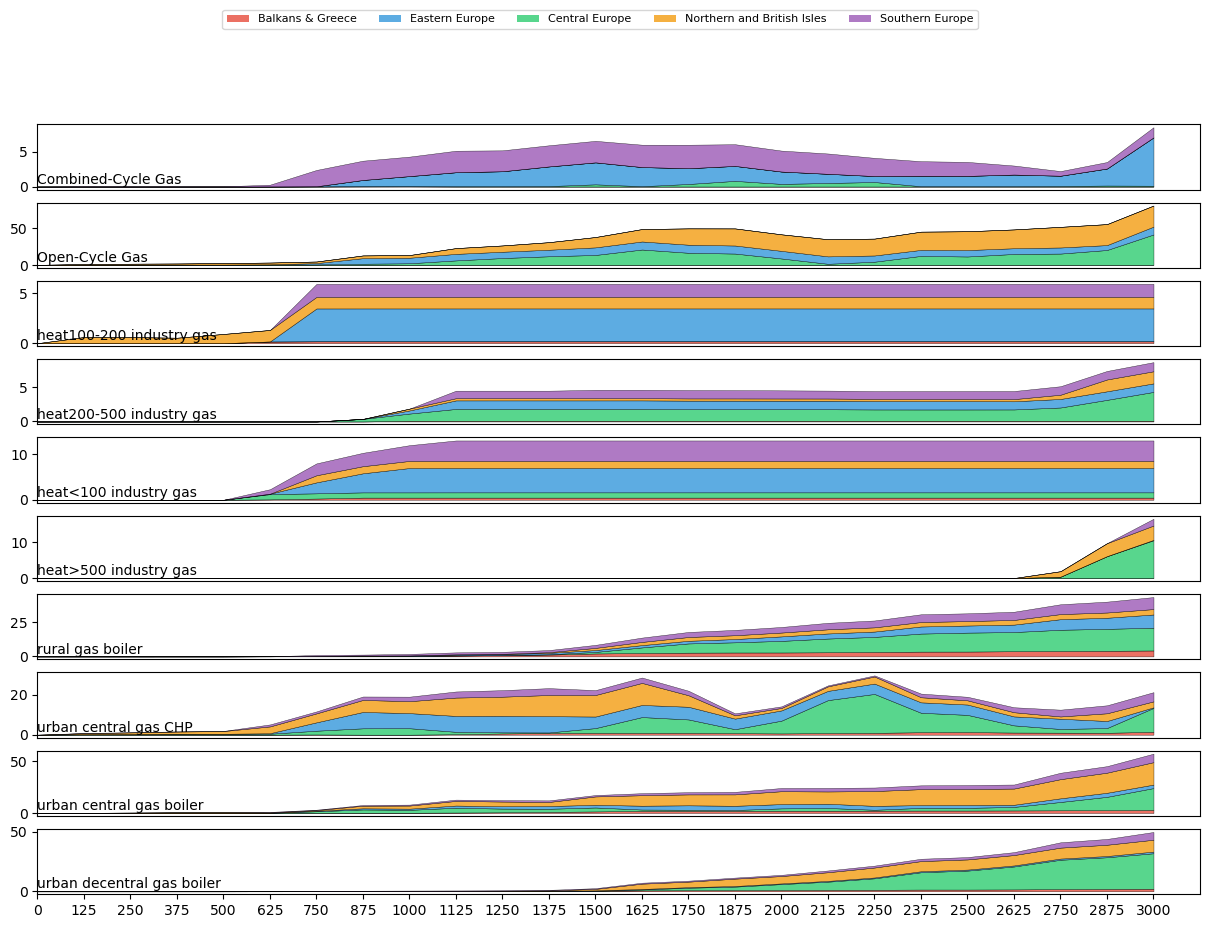

In [378]:
from matplotlib.patches import Patch

skip_carriers = [
    'SMR',
    'SMR CC',
    'gas for industry',
    'gas for industry CC',
    'heat>500 industry gas CC',
    ]

xlocks = pd.Series(range(len(caps.columns)), index=caps.columns)

# fig, ax = plt.subplots(figsize=(15, 10))
fig, axs = plt.subplots(len(caps.index.unique(0)) - len(skip_carriers), 1, figsize=(15, 10))

y_lim_upper = caps.groupby(level=0).sum().drop(skip_carriers).max().max()

i = 0

for carrier in caps.index.get_level_values(0).unique():

    if carrier in skip_carriers:
        continue

    bottoms = pd.Series(0, index=caps.columns, dtype=float)
    ax = axs[i]
    i += 1

    for region in caps.index.get_level_values(1).unique():

        row = caps.loc[carrier, region]

        x_coords = xlocks.loc[row.index].values

        bottom_values = bottoms.loc[row.index].values
        top_values = bottom_values + row.values

        ax.fill_between(
            x_coords,
            bottom_values,
            top_values, 
            color=region_colors[region], 
            alpha=0.8, 
            linewidth=0.3,
            edgecolor='black'
        )

        bottoms.loc[row.index] += row.values

    # ax.set_ylim(0, y_lim_upper)
    ax.set_xlabel('')
    ax.set_xticks([])
    ax.set_xlim(0, len(caps.columns))
    ax.text(0, 0, carrier, ha='left', va='bottom', fontsize=10)

ax = axs[-1]
ax.set_xticks(xlocks)
ax.set_xticklabels(caps.columns, rotation=0)

region_handles = [Patch(facecolor=region_colors[region], label=region, alpha=0.8)
                  for region in region_colors.keys()]

# Place legend above the figure
fig.legend(
    handles=region_handles,
    loc='upper center',
    ncol=len(region_colors),
    fontsize=8,
    bbox_to_anchor=(0.5, 1.0)
    )

plt.show()


In [302]:
caps.sum()

wiggle
1000    447082.22587
1125    373954.38289
1250    346058.41120
1375    316178.42775
1500    313745.82395
1625    312504.18976
1750    299692.85811
1875    285155.72549
2000    263673.89597
2125    262380.75920
2250    267019.10326
2375    263999.53462
2500    227271.76159
2625    205051.79658
2750    191274.62910
2875    184772.03956
3000    157957.64277
3125    147971.67113
3250    119370.06783
3375     82858.64197
3500     65679.28950
3625     49443.95472
3750     33856.78557
3875     18264.18904
4000         0.00000
dtype: float64

In [308]:
# totals_sorted = totals.loc[max_change_col.sort_values().index]

sorted_carriers

Index(['Combined-Cycle Gas', 'Open-Cycle Gas', 'SMR CC',
       'heat200-500 industry gas', 'heat>500 industry gas', 'rural gas boiler',
       'urban central gas boiler', 'urban decentral gas boiler',
       'gas for industry', 'gas for industry CC', 'heat100-200 industry gas',
       'heat<100 industry gas', 'urban central gas CHP', 'SMR',
       'heat>500 industry gas CC'],
      dtype='object', name='carrier')

In [272]:
caps.columns.unique(3)

Index(['NT+fast'], dtype='object', name='tyndp_scenario')

In [116]:
sorted(n.links.carrier.unique())

['BEV charger',
 'CCGT',
 'CO2 pipeline',
 'DC',
 'Fischer-Tropsch',
 'H2 Electrolysis',
 'HVC to air',
 'Haber-Bosch',
 'OCGT',
 'OCGT methanol',
 'SMR',
 'SMR CC',
 'Sabatier',
 'V2G',
 'agriculture machinery oil',
 'ammonia cracker',
 'battery charger',
 'battery discharger',
 'biogas to gas',
 'biomass to liquid',
 'biomass-to-methanol',
 'co2 sequestered',
 'coal for industry',
 'electricity distribution grid',
 'electrobiofuels',
 'gas for industry',
 'gas for industry CC',
 'gas pipeline',
 'gas pipeline new',
 'heat100-200 industry electric boiler steam',
 'heat100-200 industry gas',
 'heat100-200 industry gas CC',
 'heat100-200 industry industrial heat pump high temperature',
 'heat100-200 industry solid biomass',
 'heat100-200 industry solid biomass CC',
 'heat200-500 industry gas',
 'heat200-500 industry gas CC',
 'heat200-500 industry hydrogen',
 'heat200-500 industry solid biomass',
 'heat200-500 industry solid biomass CC',
 'heat>500 industry gas',
 'heat>500 industry gas

In [43]:
n.statistics()

Optimal Capacity  Installed Capacity  \
Generator Offshore Wind (AC)            2.326909e+05        2.326909e+05   
          Offshore Wind (DC)            5.463166e+03        5.463166e+03   
          Offshore Wind (Floating)      4.966501e+03        4.966501e+03   
          Onshore Wind                  4.243680e+05        4.243680e+05   
          Run of River                  4.780433e+04        4.780433e+04   
...                                              ...                 ...   
Store     gas                           1.335726e+09        1.335726e+09   
          home battery                  2.044627e+05        2.044627e+05   
          methanol                      1.777291e+04        1.777291e+04   
          non-sequestered HVC           7.931300e+08        7.931300e+08   
          oil                           7.839527e+02        7.839527e+02   

                                          Supply    Withdrawal  \
Generator Offshore Wind (AC)        8.002804e+08  0.000000e+00   
          Offshore Wind (DC)        2.362813e+07  0.000000e+00   
          Offshore Wind (Floating)  1.702802e+07  0.000000e+00   
          Onshore Wind              7.636143e+08  0.000000e+00   
          Run of River              1.620941e+08  0.000000e+00   
...                                          ...           ...   
Store     gas                       6.393956e+08  6.393956e+08   
          home battery              3.637636e+07  3.637636e+07   
          methanol                  3.703908e+04  3.703908e+04   
          non-sequestered HVC       7.931300e+08  0.000000e+00   
          oil                       7.380781e+03  7.380781e+03   

                                    Energy Balance  Transmission  \
Generator Offshore Wind (AC)          8.002804e+08           0.0   
          Offshore Wind (DC)          2.362813e+07           0.0   
          Offshore Wind (Floating)    1.702802e+07           0.0   
          Onshore Wind                7.636143e+08           0.0   
          Run of River                1.620941e+08           0.0   
...                                            ...           ...   
Store     gas                         0.000000e+00           0.0   
          home battery                2.840000e-02           0.0   
          methanol                    0.000000e+00           0.0   
          non-sequestered HVC         7.931300e+08           0.0   
          oil                         0.000000e+00           0.0   

                                    Capacity Factor   Curtailment  \
Generator Offshore Wind (AC)               0.392608  2.033953e+08   
          Offshore Wind (DC)               0.493720  6.371144e+05   
          Offshore Wind (Floating)         0.391390  2.305834e+05   
          Onshore Wind                     0.205413  1.101425e+08   
          Run of River                     0.387076  4.428229e+05   
...                                             ...           ...   
Store     gas                              0.497344  0.000000e+00   
          home battery                     0.500471  0.000000e+00   
          methanol                         0.512383  0.000000e+00   
          non-sequestered HVC              0.500579  0.000000e+00   
          oil                              0.500001  0.000000e+00   

                                    Capital Expenditure  \
Generator Offshore Wind (AC)               4.996395e+10   
          Offshore Wind (DC)               1.331982e+09   
          Offshore Wind (Floating)         1.532927e+09   
          Onshore Wind                     5.156799e+10   
          Run of River                     1.473188e+10   
...                                                 ...   
Store     gas                              2.384429e+10   
          home battery                     5.154522e+09   
          methanol                         1.000333e+05   
          non-sequestered HVC              0.000000e+00   
          oil                      

In [117]:
import pandas as pd
from pathlib import Path

In [118]:
df = pd.read_csv(Path.cwd().parent / 'results' / 'csvs' / 'prices.csv', index_col=list(range(1)), header=list(range(5)))
df.loc['gas']

cluster  opt                 planning_horizon  tyndp_scenario  wiggle
50       3H-T-H-B-I-A-dist1  2035              NT              1500      1219.137062
                                                               2000        91.657831
                                                               2500        69.812108
                                                               3000        33.688580
                                                               3500        25.081467
                                                               4000        25.080815
Name: gas, dtype: float64

In [192]:
n = pypsa.Network(Path.cwd().parent / 'results' / 'networks' / template.format(1500, ''))

INFO:pypsa.io:Imported network base_s_50__3H-T-H-B-I-A-dist1_2035_NT_1500.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [193]:
n.generators.carrier.unique()

array(['nuclear', 'offwind-float', 'offwind-ac', 'offwind-dc',
       'solar-hsat', 'onwind', 'solar', 'ror', 'gas', 'oil primary',
       'urban central heat vent', 'urban central solar thermal', 'biogas',
       'solid biomass', 'unsustainable biogas',
       'unsustainable solid biomass', 'unsustainable bioliquids', 'coal',
       'solar rooftop', 'rural heat vent', 'rural solar thermal',
       'urban decentral heat vent', 'urban decentral solar thermal',
       'co2-ets'], dtype=object)

In [202]:
carrier = 'onwind'

n.generators.loc[n.generators.carrier == carrier, ['p_nom', 'p_nom_opt', 'p_nom_min', 'p_nom_max', 'p_nom_extendable']]

,p_nom,p_nom_opt,p_nom_min,p_nom_max,p_nom_extendable
Generator,,,,,
AL0 0 0 onwind,440.185738,484.204258,396.167165,484.204312,True
AT0 0 0 onwind,12505.277662,13755.805425,11254.749896,13755.805428,True
BA0 0 0 onwind,1152.086128,1267.294692,1036.877515,1267.294741,True
BE0 0 0 onwind,6379.168283,7017.085096,5741.251454,7017.085111,True
BG0 0 0 onwind,1380.082332,1518.090557,1242.074099,1518.090565,True
CH0 0 0 onwind,730.308157,803.338948,657.277341,803.338973,True
CZ0 0 0 onwind,1729.879931,1902.867919,1556.891938,1902.867924,True
DE0 0 0 onwind,44683.195074,49151.514553,40214.875567,49151.514582,True
DE0 1 0 onwind,11776.912060,12954.603249,10599.220854,12954.603266,True


In [207]:
import pandas as pd

df1 = pd.read_csv(
    Path.cwd().parent / 'resources' / 'tyndp_capacities_2030.csv',
    index_col=0,
    header=[0,1]
)
df2 = pd.read_csv(
    Path.cwd().parent / 'resources' / 'tyndp_capacities_2035.csv',
    index_col=0,
    header=[0,1]
)

In [208]:
df1.loc[['DE', 'ES', 'FR', 'IT', 'PL']]

onwind                           offwind                         \
         LOW             NT      HIGH      LOW       NT          HIGH   
DE  115000.0  115000.700000  115000.0  30521.3  30521.3  30521.300000   
ES   45400.0   48317.494000   57200.0   2800.0   2800.0   3400.000000   
FR   28000.0   31299.999676   39000.0   3875.0   3875.0   4542.422166   
IT   16571.0   18410.819770   19332.0   8500.0   8500.0   8925.000000   
PL   10806.0   13767.840000   19000.0  10004.0  10004.0  10900.000000   

       solar                              home battery                         \
         LOW            NT           HIGH          LOW       NT          HIGH   
DE  215000.0  215002.00000  215000.000000      50538.0  50538.0  50538.000000   
ES   42937.5   64848.12700   96050.000000       1400.0   1400.0   2000.000000   
FR   23000.0   42282.19000   58000.000000          0.0      0.0      0.000000   
IT   67089.0   74600.54382  101076.993059      16000.0  16000.0  24992.180579   
PL   13885.0   21663.41000   33000.000000          0.0      0.0      0.000000   

    battery                          nuclear                      
        LOW       NT          HIGH       LOW        NT      HIGH  
DE   6400.8   6400.8   6400.800000      0.00      0.00      0.00  
ES   5000.0   5000.0   7400.000000   5100.36   5100.36   5100.36  
FR    940.0    940.0   1289.431791  59400.00  61761.00  63000.00  
IT  78765.0  78765.0  89681.353861      0.00      0.00      0.00  
PL      0.0      0.0   4691.872357      0.00      0.00   1120.00

In [209]:
df2.loc[['DE', 'ES', 'FR', 'IT', 'PL']]

onwind                            offwind                         \
         LOW             NT      HIGH       LOW       NT          HIGH   
DE  136937.5  136939.495000  141750.0  47958.45  47790.3  47790.300000   
ES   55400.0   60467.221500   75050.0   2800.00   2800.0   6400.000000   
FR   29250.0   37860.364676   50000.0  15125.00  15125.0  15602.383642   
IT   17491.0   20738.319770   22352.5  13500.00  13500.0  14637.500000   
PL   10806.0   13767.840000   29500.0  10452.00  10452.0  16350.000000   

       solar                              home battery            \
         LOW            NT           HIGH          LOW        NT   
DE  290437.5  290438.70000  307500.000000     104031.5  104031.5   
ES   57562.5   93348.12700  128949.000000       1825.0    1825.0   
FR   35000.0   54475.99500  100500.000000          0.0       0.0   
IT   70817.0   93914.54382  130121.233392      24000.0   24000.0   
PL   14891.0   23831.85000   49000.000000          0.0       0.0   

                    battery                            nuclear            \
             HIGH       LOW        NT           HIGH       LOW        NT   
DE  111377.549523   34249.9   34249.9   37145.836069      0.00      0.00   
ES    2500.000000   15500.0   15500.0   21000.000000   2550.18   2550.18   
FR       0.000000   10777.0   10777.0   22752.191844  54700.00  62334.00   
IT   38907.207061  110773.2  110773.2  129055.352698      0.00      0.00   
PL       0.000000       0.0       0.0   15611.709005   2220.00   2220.00   

              
        HIGH  
DE      0.00  
ES   2550.18  
FR  64500.00  
IT      0.00  
PL   4875.00